<a href="https://colab.research.google.com/github/yaseenddar/A-I/blob/main/Potato_Disease_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [2]:
import os

potato_data_path = os.path.join(path, 'plantvillage dataset', 'color', 'Potato___Early_blight')
print("Path to 'Potato___Early_blight' subfolder:", potato_data_path)

Path to 'Potato___Early_blight' subfolder: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Potato___Early_blight


In [3]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [4]:
IMAGE_SIZE = 256
BATCH_SIZE = 32

In [5]:
potato_class_names = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/plantvillage-dataset/plantvillage dataset/color/',
    labels='inferred',
    label_mode='int',
    class_names=potato_class_names,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


# Task
Show how to construct the path to the "potato" subfolder within the downloaded dataset.

## Access specific folder

### Subtask:
Show how to construct the path to a specific subfolder (e.g., 'potato data') within the downloaded dataset.


## Summary:

The solving process was not provided, therefore, I cannot summarize it. Please provide the solving process content to generate the summary, key findings, and insights.


In [6]:
len(dataset)

68

# Number of Batches
is 68 which contains 32 photos for every batch

In [7]:
classes = dataset.class_names
classes

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

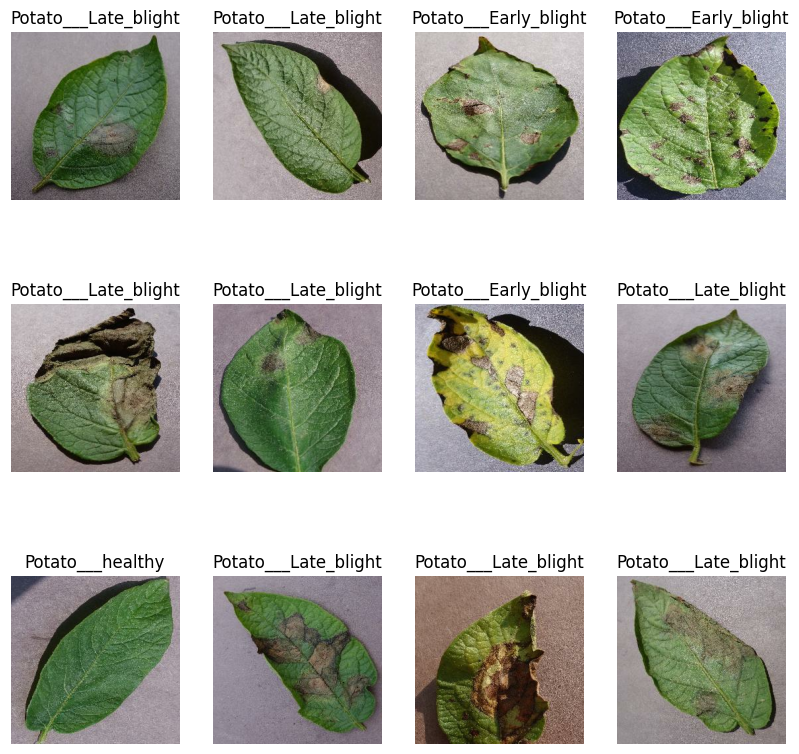

In [97]:
# Plot the data set
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(2):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype('uint8'))
    plt.axis("off")
    plt.title(potato_class_names[label_batch[i]])

# the is the color for three types of data
32 batches [][][][]....
each batch of [256,256]...


In [ ]:
# 80% ==> training
# 20% ==> validate
# 10% == > test

In [9]:
train_size = 0.8
train_size = int(len(dataset)*train_size)

In [10]:
train_data = dataset.take(train_size)

In [11]:
len(train_data)

54

In [12]:
valid_data = dataset.skip(train_size)
len(valid_data)

14

In [13]:
test_data = valid_data.skip(6)
len(test_data)

8

In [19]:
def split_the_data(dataset,train_per=0.8,valid_per=0.1,test_per=0.1,shuffle=True):
  if shuffle:
    dataset = dataset.shuffle(3,12)

  # train data set
  train_data_size = int(len(dataset)*train_per)
  train_data = dataset.take(train_data_size)

  # validation data

  valid_data_size = int(len(dataset)*valid_per)
  valid_data = dataset.skip(train_data_size)

  # test data
  test_data_size = int(len(dataset)*test_per)
  test_data = valid_data.skip(test_data_size)

  return train_data,valid_data,test_data








In [20]:
train_data,valid_data,test_data = split_the_data(dataset)

In [21]:
print(len(train_data))
print(len(valid_data))
print(len(test_data))

54
14
8


In [25]:
#  we do caching in for faster access shulle the images prefetch and make augmentation
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
valid_data = valid_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
#

In [28]:
# we do now the preprocessing to the data
resize_and_rescale = tf.keras.Sequential([
tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
tf.keras.layers.Rescaling(1.0/255)
 ])

In [31]:
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip("horizontal_and_vertical"),
tf.keras.layers.RandomRotation(0.2)
])

In [59]:
model = tf.keras.models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape =(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,3)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(3,activation='softmax')
])

In [60]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [64]:
model.fit(
    train_data,
    batch_size=BATCH_SIZE,
    validation_data=valid_data,
    verbose=1,
    epochs=50
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6840 - loss: 0.7132 - val_accuracy: 0.6368 - val_loss: 0.8779
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8502 - loss: 0.3647 - val_accuracy: 0.9175 - val_loss: 0.2126
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8970 - loss: 0.2364 - val_accuracy: 0.8373 - val_loss: 0.4271
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8395 - loss: 0.4002 - val_accuracy: 0.7995 - val_loss: 0.4383
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9013 - loss: 0.2657 - val_accuracy: 0.8797 - val_loss: 0.2924
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9205 - loss: 0.2296 - val_accuracy: 0.9080 - val_loss: 0.2298
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8951 - loss: 0.2761 - val_accuracy: 0.9387 - val_loss: 0.1369
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9509 - loss: 0.1322 - val_accuracy: 0.9528 - v

In [65]:
# now we predict
model.predict(test_data)

In [86]:
import numpy as np

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
predicted label: Potato___Late_blight
first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
predicted label: Potato___Early_blight
first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
predicted label: Potato___Early_blight


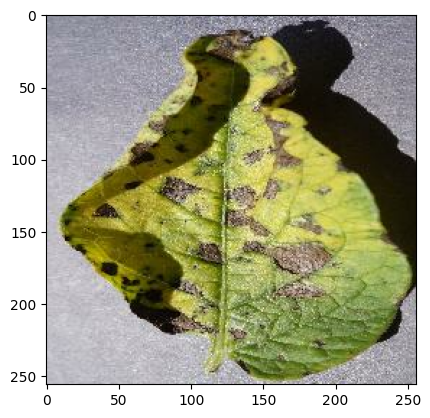

In [99]:
# use model predict the teste
# model_prediction = model.predict()
for image_batch,label_batch in test_data.take(3):
  first_image = image_batch[0].numpy().astype('uint8')
  first_label = label_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:",classes[first_label])

  batch_prediction = model.predict(image_batch)
  print("predicted label:",classes[np.argmax(batch_prediction[0])])
